In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
dataset = pd.read_csv('Salary.csv')
dataset.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [15]:
print("Shape:", dataset.shape)
print("\nStatistics:")
dataset.describe()

Shape: (35, 2)

Statistics:


,YearsExperience,Salary
count,35.000000,35.000000
mean,6.308571,83945.600000
std,3.618610,32162.673003
min,1.100000,37731.000000
25%,3.450000,57019.000000
50%,5.300000,81363.000000
75%,9.250000,113223.500000
max,13.500000,139465.000000


In [16]:
print("Missing values:")
print(dataset.isnull().sum())

Missing values:
YearsExperience    0
Salary             0
dtype: int64


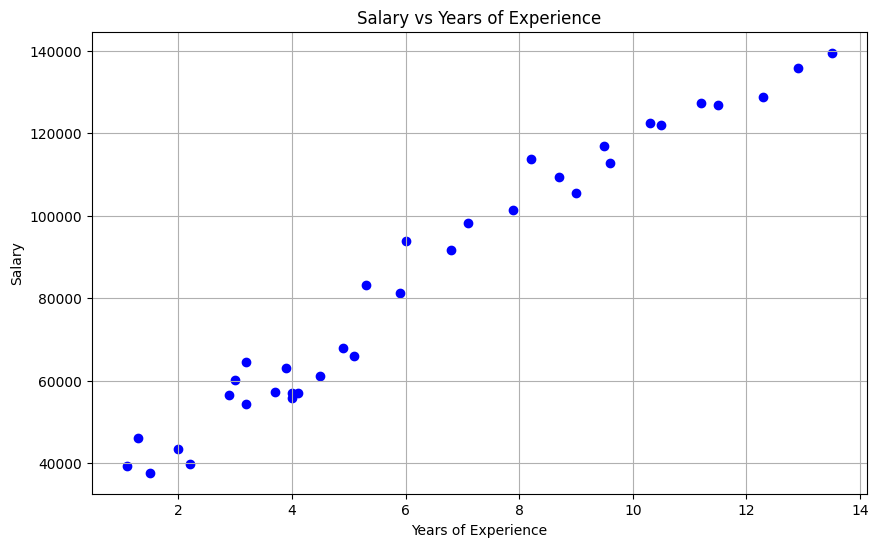

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['YearsExperience'], dataset['Salary'], color='blue')
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X = dataset[['YearsExperience']]
y = dataset['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size: ", X_test.shape)

Training size: (28, 1)
Testing size:  (7, 1)


In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Slope (m): 8578.767476685925
Intercept (b): 29078.626034406887


In [20]:
y_pred = model.predict(X_test)

print("Actual Salaries:   ", list(y_test))
print("Predicted Salaries:", [round(float(p), 2) for p in y_pred])

Actual Salaries:    [116969, 57081, 109431, 98273, 67938, 121872, 93940]
Predicted Salaries: [110576.92, 64251.57, 103713.9, 89987.88, 71114.59, 119155.68, 80551.23]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("MAE  (Mean Absolute Error)  :", round(mae, 2))
print("MSE  (Mean Squared Error)   :", round(mse, 2))
print("RMSE (Root Mean Sq. Error)  :", round(rmse, 2))
print("R²   (R-Squared Score)      :", round(r2, 4))

MAE  (Mean Absolute Error)  : 6692.36
MSE  (Mean Squared Error)   : 55761791.31
RMSE (Root Mean Sq. Error)  : 7467.38
R²   (R-Squared Score)      : 0.8914


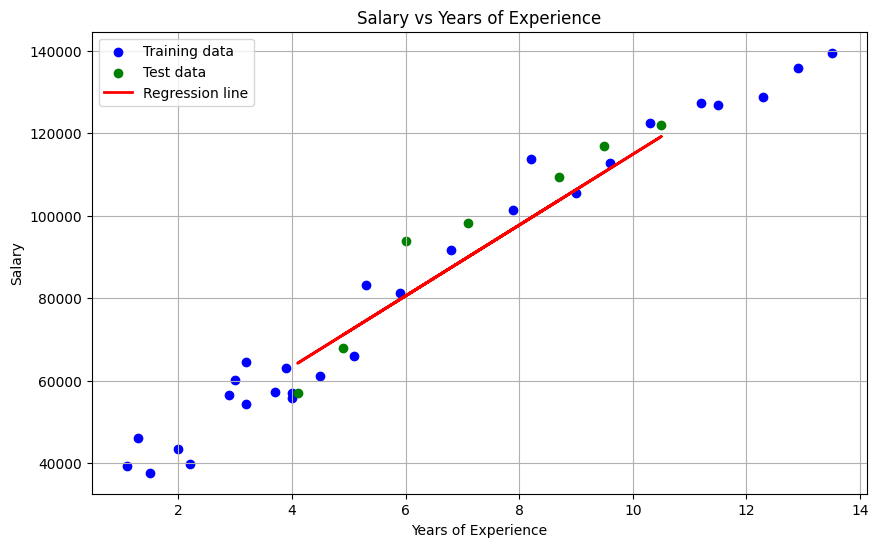

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test,  y_test,  color='green', label='Test data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import joblib

joblib.dump(model, 'salary_model.pkl')
print("Model saved successfully!")

loaded_model = joblib.load('salary_model.pkl')
print("Model loaded successfully!")

Model saved successfully!
Model loaded successfully!


In [24]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

def predict_salary(years):
    input_data = pd.DataFrame([[years]], columns=['YearsExperience'])
    prediction = loaded_model.predict(input_data)
    return round(float(prediction[0]), 2)

years_input = widgets.FloatText(
    value=5.0,
    step=0.1,
    description='Years of Experience:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

output = widgets.Output()

def on_change(change):
    with output:
        output.clear_output()
        salary = predict_salary(change['new'])
        print(f"─────────────────────────────────")
        print(f"Years of experience : {change['new']}")
        print(f"Predicted salary    : ${salary:,.2f}")
        print(f"─────────────────────────────────")

years_input.observe(on_change, names='value')

print("── Salary Predictor ──")
display(years_input, output)

── Salary Predictor ──


FloatText(value=5.0, description='Years of Experience:', layout=Layout(width='300px'), step=0.1, style=Descrip…

Output()